<a href="https://colab.research.google.com/github/VukasinA/ML_projekti/blob/main/DomaciPrepoznavanjeGovora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers soundfile torch

In [ ]:
!pip install librosa webrtcvad soundfile matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp312-cp312-linux_x86_64.whl size=73514 sha256=578736764e15062f75d7ebdedc26dfbf582a9a7e9ed3cd395a6ea809d72253ed
  Stored in directory: /root/.cache/pip/wheels/1e/d3/95/680fa3b16848f1a58d2edaed34c496224c89a9bc63e17b3614
Successfully built webrtcvad


In [ ]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import webrtcvad

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Recording (2).m4a to Recording (2).m4a


In [ ]:
# Ime fajla (uzima prvi uploadovan fajl)
filename = list(uploaded.keys())[0]

# Učitavanje
signal, sr = librosa.load(filename, sr=16000)

print("Sampling rate:", sr)
print("Dužina signala (s):", len(signal) / sr)

/tmp/ipython-input-4261049845.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, sr = librosa.load(filename, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Sampling rate: 16000
Dužina signala (s): 6.229375


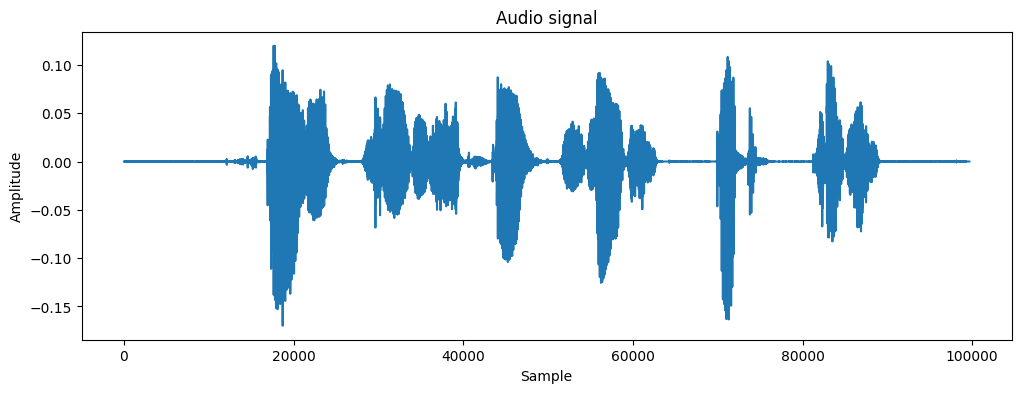

In [ ]:
#vizuelizacija signala
plt.figure(figsize=(12, 4))
plt.plot(signal)
plt.title("Audio signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
#parametri
SAMPLE_RATE = 16000
FRAME_DURATION = 0.25  # sekunde
FRAME_SIZE = int(SAMPLE_RATE * FRAME_DURATION)
RMS_THRESHOLD = 0.01


In [ ]:
def compute_rms(signal):
    return np.sqrt(np.mean(signal ** 2))

def vad_rms(signal, threshold=RMS_THRESHOLD):
    rms = compute_rms(signal)
    return 1 if rms > threshold else 0 #1 govor 0 tisina


In [ ]:
vad_results = []

for i in range(0, len(signal), FRAME_SIZE):
    frame = signal[i:i + FRAME_SIZE]

    if len(frame) < FRAME_SIZE:
        break

    speech = vad_rms(frame)
    vad_results.append(speech)

    print("Govor" if speech else "Tišina")


Tišina
Tišina
Tišina
Tišina
Govor
Govor
Tišina
Govor
Govor
Govor
Tišina
Govor
Tišina
Govor
Govor
Tišina
Tišina
Govor
Tišina
Tišina
Govor
Govor
Tišina
Tišina


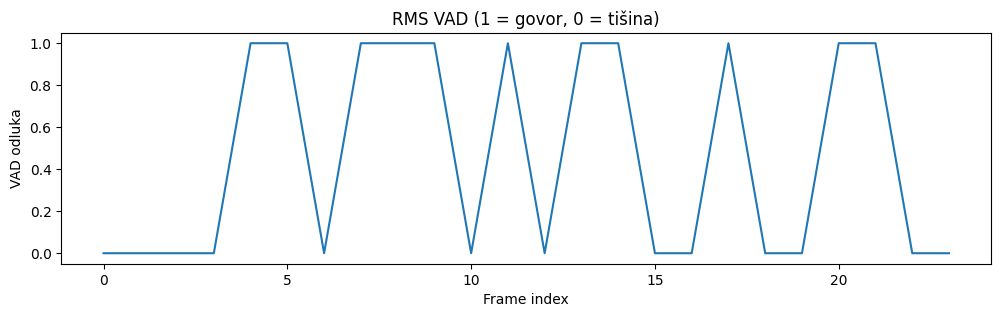

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(vad_results)
plt.title("RMS VAD (1 = govor, 0 = tišina)")
plt.xlabel("Frame index")
plt.ylabel("VAD odluka")
plt.show()


In [ ]:
vad = webrtcvad.Vad(0)  # agresivnost 0–3

In [ ]:
def float_to_pcm16(signal):
    pcm = np.int16(signal / np.max(np.abs(signal)) * 32767)
    return pcm.tobytes()

In [ ]:
FRAME_MS = 20
FRAME_SIZE_WEBRTC = int(SAMPLE_RATE * FRAME_MS / 1000)

# primer segmenta tišine u signalu
signal[0:1600] = 0  # 0.1s tišina

vad_results_webrtc = []

for i in range(0, len(signal), FRAME_SIZE_WEBRTC):
    frame = signal[i:i + FRAME_SIZE_WEBRTC]

    if len(frame) < FRAME_SIZE_WEBRTC:
        break

    pcm_frame = float_to_pcm16(frame)
    speech = vad.is_speech(pcm_frame, SAMPLE_RATE)

    vad_results_webrtc.append(int(speech))

/tmp/ipython-input-2722145925.py:2: RuntimeWarning: invalid value encountered in divide
  pcm = np.int16(signal / np.max(np.abs(signal)) * 32767)
/tmp/ipython-input-2722145925.py:2: RuntimeWarning: invalid value encountered in cast
  pcm = np.int16(signal / np.max(np.abs(signal)) * 32767)


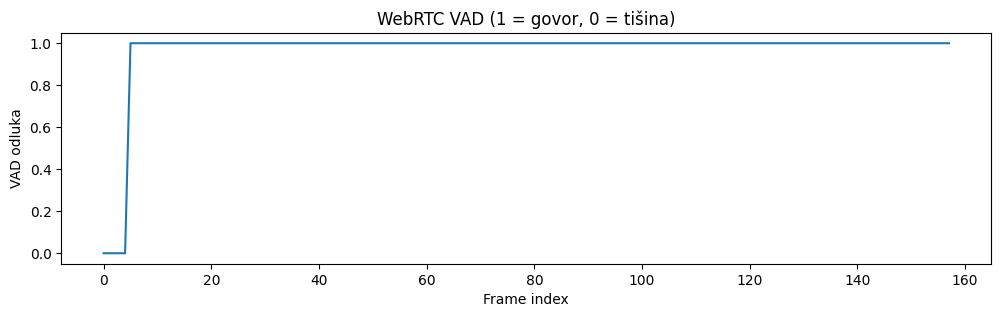

In [ ]:
plt.figure(figsize=(12, 3))
plt.plot(vad_results_webrtc)
plt.title("WebRTC VAD (1 = govor, 0 = tišina)")
plt.xlabel("Frame index")
plt.ylabel("VAD odluka")
plt.show()


In [ ]:
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
import soundfile as sf

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

processor = Wav2Vec2Processor.from_pretrained("classla/wav2vec2-xls-r-juznevesti-sr")
model = Wav2Vec2ForCTC.from_pretrained("classla/wav2vec2-xls-r-juznevesti-sr").to(device)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/214 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

In [ ]:
# učitaj fajl (možeš koristiti signal koji si već učitao)
sf.write("temp_input.wav", signal, sr)  # sačuvaj signal u .wav

speech, sr2 = sf.read("temp_input.wav")

inputs = processor(speech, sampling_rate=sr2, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(inputs.input_values.to(device)).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)[0]

print("Transkripcija:", transcription)


Transkripcija: da li želiš da znaš kada ćeš


In [ ]:
#delimo nas govor na segmente, ali wave2vec ne voli kratke segmente
govor_frames = []

for i in range(0, len(signal), FRAME_SIZE):
    frame = signal[i:i + FRAME_SIZE]

    if len(frame) < FRAME_SIZE:
        break

    if vad_rms(frame) == 1:   # samo govor
        govor_frames.append(frame)

print("Broj govornih segmenata:", len(govor_frames))


Broj govornih segmenata: 7


In [ ]:
import soundfile as sf

for idx, frame in enumerate(govor_frames):
    sf.write(f"segment_{idx}.wav", frame, sr)

    speech, sr2 = sf.read(f"segment_{idx}.wav")

    inputs = processor(
        speech,
        sampling_rate=sr2,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        logits = model(inputs.input_values.to(device)).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    text = processor.batch_decode(predicted_ids)[0]

    print(f"[Segment {idx}]: {text}")


[Segment 0]: pa
[Segment 1]: i
[Segment 2]: a
[Segment 3]: 
[Segment 4]: am
[Segment 5]: 
[Segment 6]: o


In [ ]:
!pip install requests

In [ ]:
import requests
import time

SERVICE_URL = "http://localhost:5000/transcription"

In [ ]:
def transcription_service(payload):
    print("📡 Servis primio tekst:")
    print(payload["text"])
    return {"status": "ok"}


In [ ]:
import time

predicted_texts = []

for idx, frame in enumerate(govor_frames):
    inputs = processor(frame, sampling_rate=sr, return_tensors="pt", padding=True)

    with torch.no_grad():
        logits = model(inputs.input_values.to(device)).logits

    predicted_ids = torch.argmax(logits, dim=-1)
    text = processor.batch_decode(predicted_ids)[0]

    predicted_texts.append(text)

    # PERIODIČNO "SLANJE SERVISU"
    if idx % 2 == 0:
        payload = {"text": " ".join(predicted_texts)}
        response = transcription_service(payload)
        print("Poslato servisu")

    time.sleep(1)

📡 Servis primio tekst:
pa
Poslato servisu
📡 Servis primio tekst:
pa i a
Poslato servisu
📡 Servis primio tekst:
pa i a  am
Poslato servisu
📡 Servis primio tekst:
pa i a  am  o
Poslato servisu
